In [1]:
import warnings 
warnings.filterwarnings('ignore') 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm 
from statsmodels.formula.api import ols 
import numpy as np

In [2]:
%store -r df 
df =df 

%store -r numrical_cols 

num_cols = numrical_cols 

%store -r cat_cols 

cat_cols = cat_cols 

In [3]:
df

,Brand,Model,Year,EngineSize,Fuel,Transmission,Mileage,Doors,OwnerCount,Price
9254,Volkswagen,Golf,2007,3.2,Hybrid,Semi-Automatic,33948,5,4,9721
1561,BMW,5 Series,2010,4.8,Electric,Semi-Automatic,224853,2,1,9402
1670,Hyundai,Sonata,2006,1.9,Hybrid,Semi-Automatic,13435,3,5,8531
6087,Honda,CR-V,2019,1.7,Diesel,Semi-Automatic,199846,2,3,7503
6669,Mercedes,E-Class,2005,3.6,Petrol,Automatic,261,3,2,10694
...,...,...,...,...,...,...,...,...,...,...
5734,BMW,X5,2009,1.8,Petrol,Semi-Automatic,281531,4,1,2969
5191,Honda,CR-V,2015,4.5,Electric,Semi-Automatic,223211,3,5,10635
5390,BMW,X5,2006,4.5,Petrol,Semi-Automatic,54111,5,5,9317
860,Toyota,RAV4,2016,4.4,Diesel,Semi-Automatic,265121,3,4,7997


In [4]:
cat_cols

['Brand', 'Model', 'Fuel', 'Transmission']

In [5]:
num_cols

['Year', 'EngineSize', 'Mileage', 'Doors', 'OwnerCount', 'Price']

# Descriptive Analysis

- #### **Numerical Data** 

#### make analysis for Quntitative variables 

- will find measure of central tendency 
- Dispersion (std) 
- and draw distribution plots to compare it between normal dist

In [6]:
""" 
    will implement KDE plot to show desity of data
    
""" 

def kde_plot(col) : 
    # show figure proprity 
    sns.set_style('white')
    plt.figure(figsize= (12 , 3)) 

    sns.histplot(df[col] , kde=True, stat='density' , color='#2c3e50' , alpha = 0.2 , linewidth = 0) 

    sns.kdeplot(df[col] , color='#2980b2' , lw = 3)


    mean = df[col].mean() 
    median = np.median(df[col])

    plt.axvline(mean , color = 'black' , linestyle = 'dashed')
    plt.axvline(median , color = 'green' , linestyle = 'solid') 

    plt.title(f'Distribution Analysis of {col}', fontsize=14, pad=20)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.tight_layout()

    return plt.show()
    

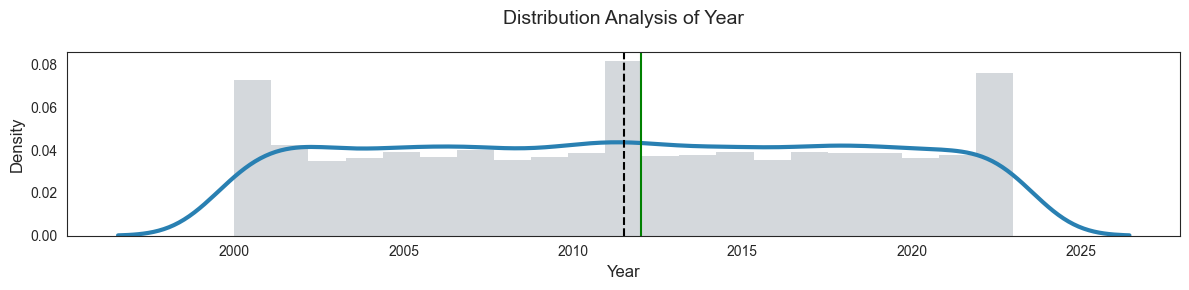

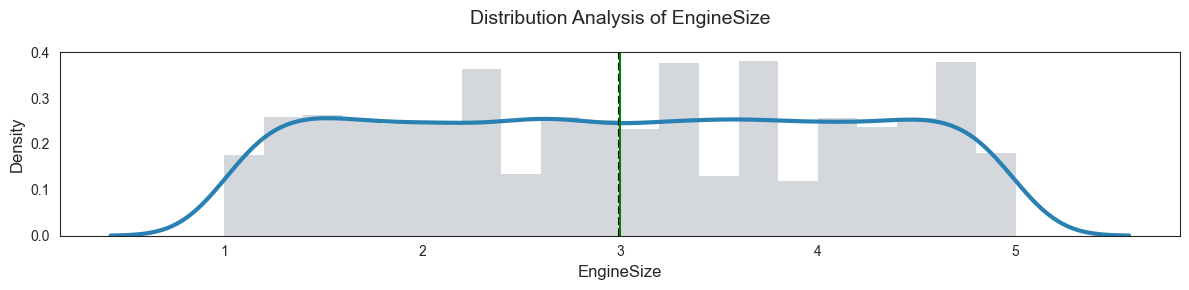

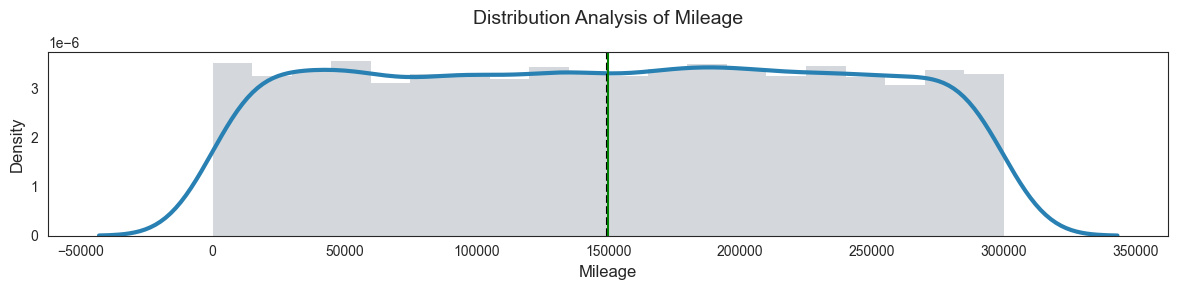

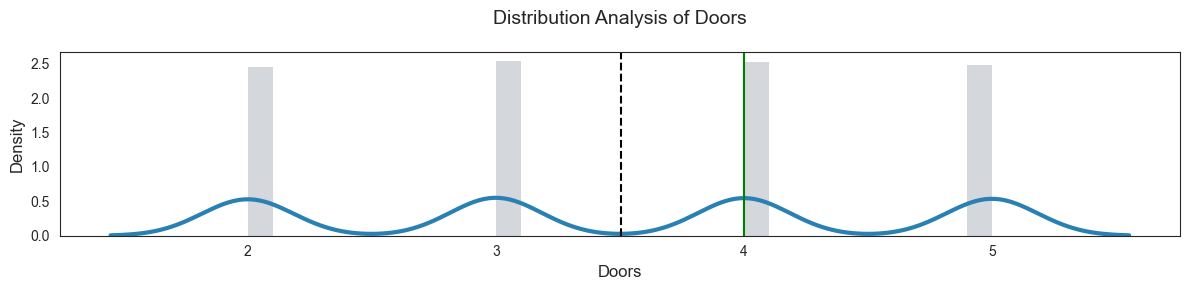

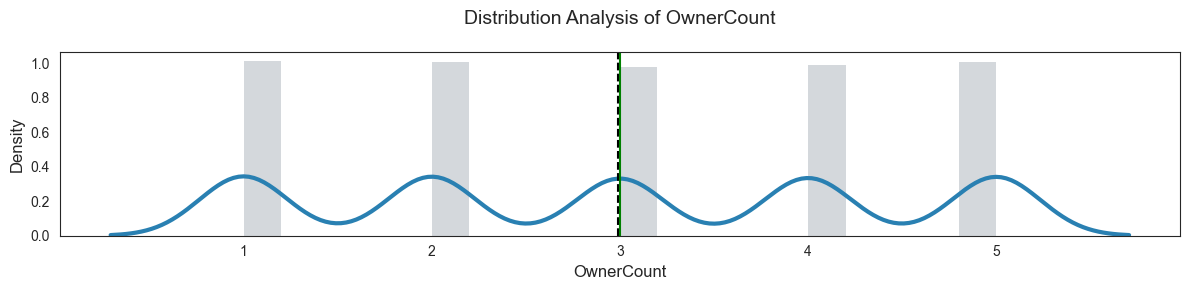

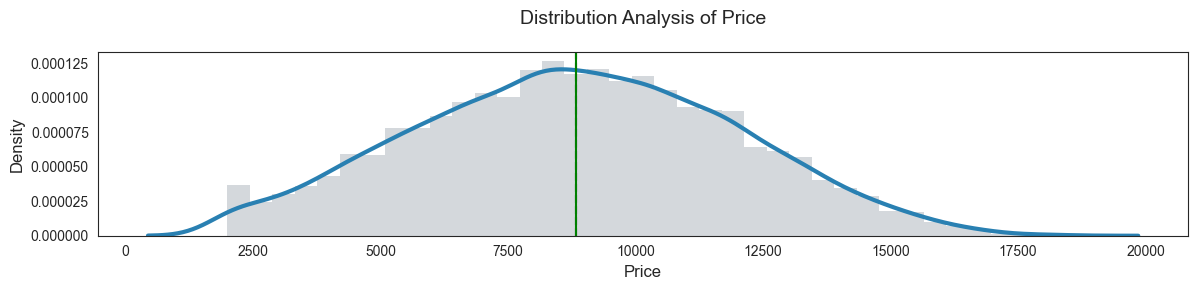

In [7]:
for col in num_cols : 
    kde_plot(col) 

#### none of the above columns need transfcormation later 

# categorical Data

#### here we can find the mode of categorical columns to see which category repeated more that reset  

In [8]:
cat_cols 

['Brand', 'Model', 'Fuel', 'Transmission']

In [9]:
print(cat_cols[0] , ' -> ',df[cat_cols[0]].mode()[0])
print(cat_cols[1] , ' -> ',df[cat_cols[1]].mode()[0])
print(cat_cols[2] , ' -> ',df[cat_cols[2]].mode()[0])
print(cat_cols[3] , ' -> ',df[cat_cols[3]].mode()[0])

Brand  ->  Audi
Model  ->  Accord
Fuel  ->  Electric
Transmission  ->  Manual


# correlation analysis

- ### start with numerical columns (use person correlation) 

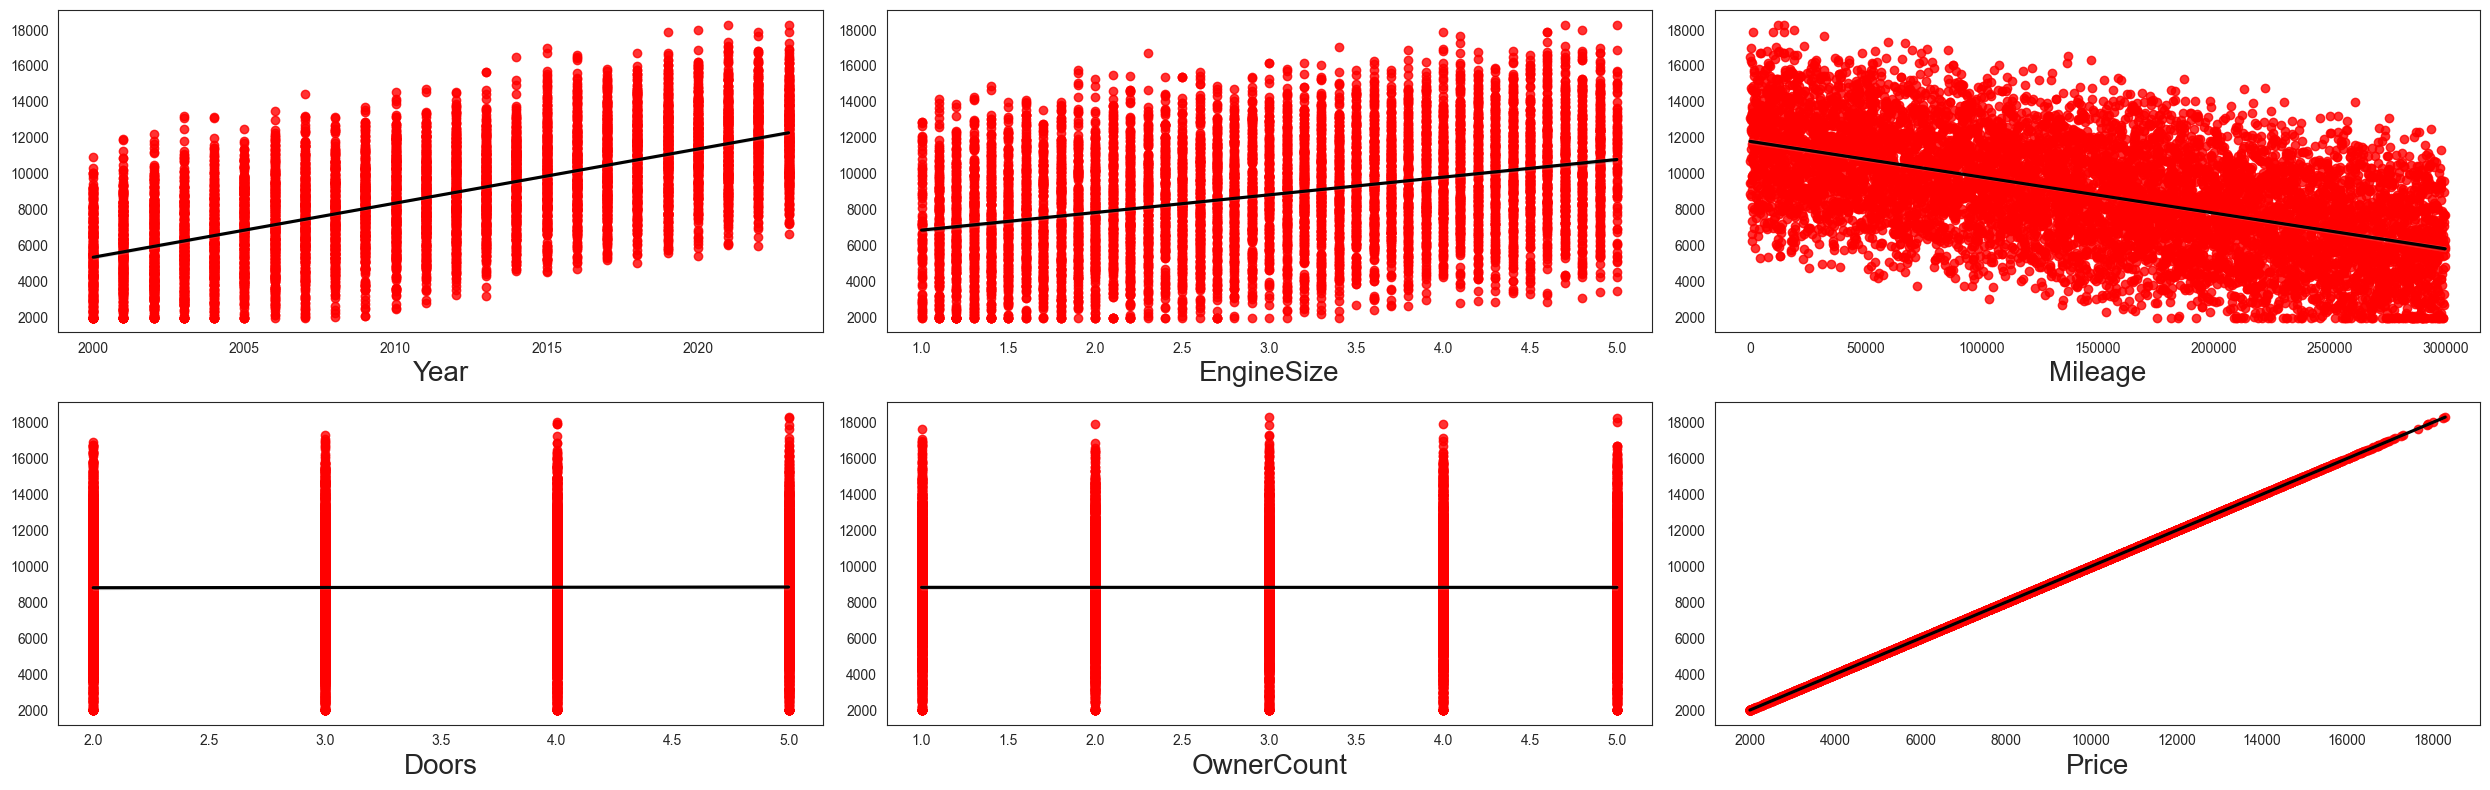

In [10]:
fig , ax = plt.subplots(2 , 3 , figsize = (25 , 8)) 

ax = ax.ravel() # mazke grid  2*3 in 1D array has 6 element to iterate over it 

for i , col in enumerate(num_cols): 
    sns.regplot(
        x = col , 
        y = 'Price' , 
        data = df , 
        ax = ax[i] , 
        scatter_kws={'color':"red"} , 
        line_kws= {"color" : 'black'}) 
    
    ax[i].set_xlabel(col,fontsize = 20) 
    ax[i].set_ylabel('') 

plt.tight_layout() 
plt.show()    

### insights 

- #### Newer models have higher price then they have postive relationship 
- #### the car with bigger engin size  have higer price and they have `postive` relationship 
- #### the car with higher mileage have lower price and they have `neg ` relationship  


### Now will use Heatmap to calculate Person correlation 

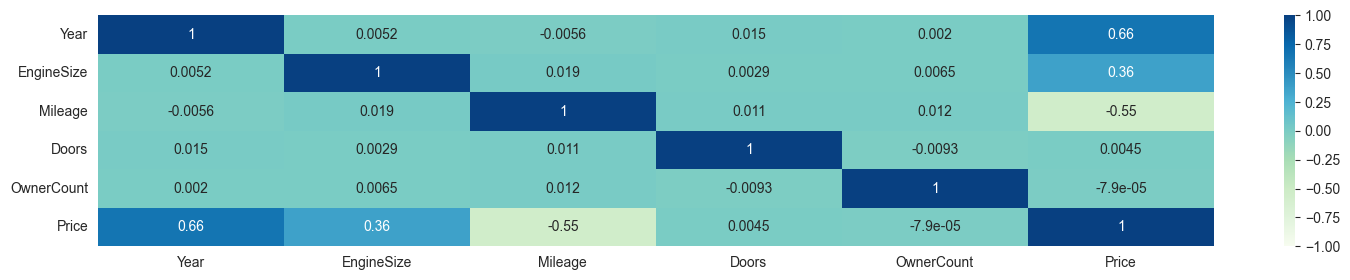

In [11]:
pearson_corr = df[num_cols].corr(method = 'pearson') 
plt.figure(figsize=(18 , 3)) 

sns.heatmap(pearson_corr,
            vmin=-1 , 
            vmax = 1 , 
            cmap='GnBu' , 
            annot=True) 

plt.show()


### Categorical Data (ANOVA test)

In [12]:
for i in cat_cols : 

    formula = f'Price ~ {i}' 

    model = ols(formula , data=df).fit() 

    anova = sm.stats.anova_lm(model , typ = 2) 

    p_value = anova.iloc[ 0 , 3 ] 

    print(f'P_value for Price ~ {i} : {p_value}')

P_value for Price ~ Brand : 0.18317562683905464
P_value for Price ~ Model : 0.5977964773758024
P_value for Price ~ Fuel : 1.1608569649130529e-129
P_value for Price ~ Transmission : 6.731887149600459e-116


### By this result , We can come up that 

`fule` and `transmission` ara explain price Becase the `P_value < 0.05` 

### let make group by function to aggregate each function with price 

In [13]:
def mean_pairwise(cat_col) : 
    mean_by = df.groupby(cat_col)['Price'].mean() 
    mean_by = pd.DataFrame(mean_by) 
    mean_by.sort_values(by=['Price'] , inplace=True , ascending=False) 

    return mean_by.head(5)  

In [14]:
for i in cat_cols : 
    print(mean_pairwise(i))

                  Price
Brand                  
Chevrolet   9018.451815
Audi        8931.886016
Volkswagen  8901.128019
Mercedes    8892.547554
Kia         8885.963731
               Price
Model               
Tiguan   9146.532423
Impala   9094.073944
Equinox  9093.704453
Q5       9028.094406
Corolla  8995.060377
                 Price
Fuel                  
Electric  10061.022662
Hybrid     9094.456689
Diesel     8091.958829
Petrol     8017.726901
                      Price
Transmission               
Automatic       9954.639456
Manual          8338.461027
Semi-Automatic  8204.673971
